<h1 align="center">Sentiment Analysis of Real-time Flipkart Product Reviews</h1>

In [87]:
# =========================
# Core libraries
# =========================

import numpy as np                  # Numerical operations (arrays, math, vectorized ops)
import pandas as pd                 # Data manipulation (DataFrames, CSVs, cleaning)
import math                         # Mathematical functions (log, sqrt, etc.)

# =========================
# Data Visualization
# =========================

import matplotlib.pyplot as plt     # Basic plotting (line, bar, histograms)
import seaborn as sns               # Advanced statistical plots (heatmaps, countplots)

# =========================
# Text Preprocessing (NLP)
# =========================

import re                           # Regular expressions for text cleaning
import nltk                         # Natural Language Toolkit (NLP utilities)

from nltk.tokenize import word_tokenize      # Split text into individual words
from nltk.corpus import stopwords             # Common words like "the", "is", "and"
from nltk.stem.porter import PorterStemmer    # Reduce words to base form (loved → love)
from nltk.stem import WordNetLemmatizer       # Smarter word normalization (better than stemming)

# =========================
# Utilities
# =========================

from tqdm import tqdm, tqdm_notebook # Progress bars for loops (useful for large datasets)
from wordcloud import WordCloud      # Visualize frequent words as a word cloud

# =========================
# Machine Learning
# =========================

from sklearn.model_selection import train_test_split   # Split data into train/test sets
from sklearn.feature_extraction.text import (
    CountVectorizer, 
    TfidfVectorizer
)                                                      # Convert text into numbers

from sklearn.linear_model import LogisticRegression    # Linear classifier for sentiment
from sklearn.naive_bayes import MultinomialNB          # Fast probabilistic text classifier
from sklearn.svm import LinearSVC                      # Support Vector Machine for text data
from sklearn.neighbors import KNeighborsClassifier     # Distance-based classifier using nearest neighbors
from sklearn.tree import DecisionTreeClassifier        # Tree-based model using decision rules
from sklearn.ensemble import RandomForestClassifier    # Ensemble of decision trees for better accuracy

from sklearn.model_selection import GridSearchCV       # Hyperparameter tuning

from sklearn.metrics import (
    accuracy_score,
    classification_report, 
    f1_score
)                                                      # Model evaluation metrics

## Loading Dataset

In [2]:
df = pd.read_csv("YONEX MAVIS 350 Nylon Shuttle.csv")

In [3]:
df.head()  # Display first 5 rows

,Reviewer Name,Review Title,Place of Review,Up Votes,Down Votes,Month,Review text,Ratings
0,Kamal Suresh,Nice product,"Certified Buyer, Chirakkal",889.0,64.0,Feb 2021,"Nice product, good quality, but price is now r...",4
1,Flipkart Customer,Don't waste your money,"Certified Buyer, Hyderabad",109.0,6.0,Feb 2021,They didn't supplied Yonex Mavis 350. Outside ...,1
2,A. S. Raja Srinivasan,Did not meet expectations,"Certified Buyer, Dharmapuri",42.0,3.0,Apr 2021,Worst product. Damaged shuttlecocks packed in ...,1
3,Suresh Narayanasamy,Fair,"Certified Buyer, Chennai",25.0,1.0,NaN,"Quite O. K. , but nowadays the quality of the...",3
4,ASHIK P A,Over priced,NaN,147.0,24.0,Apr 2016,Over pricedJust â?¹620 ..from retailer.I didn'...,1


In [4]:
df.shape 

(8518, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8518 entries, 0 to 8517
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Reviewer Name    8508 non-null   object 
 1   Review Title     8508 non-null   object 
 2   Place of Review  8468 non-null   object 
 3   Up Votes         8508 non-null   float64
 4   Down Votes       8508 non-null   float64
 5   Month            8053 non-null   object 
 6   Review text      8510 non-null   object 
 7   Ratings          8518 non-null   int64  
dtypes: float64(2), int64(1), object(5)
memory usage: 532.5+ KB


#### Observations:
- Dataset contains 8,518 reviews with ratings, review text, and metadata
- Review text is the primary carrier of sentiment
- Ratings are available and can be used to derive sentiment labels

## Objective:

To classify customer reviews into Positive, Neutral, and Negative sentiments using Natural Language Processing techniques.

1. Target & Input Features

Target Variable: sentiment (derived from ratings)

Primary Input Feature: Review text (combined with Review Title)

2. Features Not Used

Reviewer Name

Place of Review

Month

Up Votes / Down Votes

These fields do not contribute to text-based sentiment learning and are excluded to keep the model focused and efficient.

## Data Cleaning & Missing Value Handling

In [6]:
df.isnull().sum()

Reviewer Name       10
Review Title        10
Place of Review     50
Up Votes            10
Down Votes          10
Month              465
Review text          8
Ratings              0
dtype: int64

In [15]:
df[df.isna().any(axis=1)]

,Reviewer Name,Review Title,Place of Review,Up Votes,Down Votes,Month,Review text,Ratings
3,Suresh Narayanasamy,Fair,"Certified Buyer, Chennai",25.0,1.0,NaN,"Quite O. K. , but nowadays the quality of the...",3
4,ASHIK P A,Over priced,NaN,147.0,24.0,Apr 2016,Over pricedJust â?¹620 ..from retailer.I didn'...,1
32,Pankaj Srivastava,Slightly disappointed,"Certified Buyer, New Delhi",2.0,0.0,NaN,"After using, found shuttles quality are not up...",2
33,rajath,Did not meet expectations,"Certified Buyer, Mysore",2.0,0.0,NaN,Local productREAD MORE,1
34,vijay chaudhari,Not good,"Certified Buyer, Pimpri Chinchwad",2.0,0.0,NaN,Few of shuttle just separated from base in jus...,2
...,...,...,...,...,...,...,...,...
8504,naresh g,For Mavis350,NaN,2.0,1.0,Aug 2016,Received product intact and sealedREAD MORE,5
8505,MD. Jabbar,Very Good,NaN,1.0,0.0,Sep 2016,Delivered before time but price is high from m...,3
8506,Abani Behera,Don't waste your money,NaN,0.0,2.0,Sep 2016,up to the mark but same is available in market...,4
8508,NaN,,NaN,NaN,NaN,NaN,No complaints about the item . Its the best on...,5


#### Observations:
- Some rows contain ratings but missing review text
- Such rows cannot be used for sentiment modeling
- Review titles are optional but informative

In [12]:
# Drop rows with missing review text (cannot be used)
df = df.dropna(subset=["Review text"])

# Fill optional text columns
df["Review Title"] = df["Review Title"].fillna("")

#### Action Taken
- Rows with missing Review text are removed
- Missing Review Title values are replaced with empty strings
- Metadata-related missing values are ignored as they are not used

In [13]:
# Check remaining missing values
df.isnull().sum()

Reviewer Name        2
Review Title         0
Place of Review     42
Up Votes             2
Down Votes           2
Month              457
Review text          0
Ratings              0
dtype: int64

In [9]:
df.Ratings.value_counts()

Ratings
5    5079
4    1744
1     766
3     615
2     306
Name: count, dtype: int64

### Create Sentiment Labels (3-Class)

We convert numerical star ratings into categorical sentiment labels.

**Label Mapping**

1–2 stars → Negative

3 stars → Neutral

4–5 stars → Positive

**Note**: After creating sentiment labels, the Ratings column is dropped to avoid data leakage and to simulate real-world inference conditions.

In [18]:
def label_sentiment(rating):
    """
    Convert star rating into sentiment category
    """
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

# Apply sentiment labeling
df["sentiment"] = df["Ratings"].apply(label_sentiment)

In [19]:
# Check class distribution
df["sentiment"].value_counts()

sentiment
Positive    6823
Negative    1072
Neutral      615
Name: count, dtype: int64

In [20]:
# Dropping the Ratings col to prevent data leakage
df = df.drop(columns=["Ratings"])

### Text Combination

In [21]:
# We merge the review title and review text to strengthen sentiment signals.
df["full_review"] = df["Review Title"] + " " + df["Review text"]

df[["full_review"]].head()

,full_review
0,"Nice product Nice product, good quality, but p..."
1,Don't waste your money They didn't supplied Yo...
2,Did not meet expectations Worst product. Damag...
3,"Fair Quite O. K. , but nowadays the quality o..."
4,Over priced Over pricedJust â?¹620 ..from reta...


## Text Cleaning & Normalization

We normalize the text to reduce noise and standardize vocabulary.

**Techniques Used**
- Lowercasing
- Removing special characters and numbers
- Stopword removal
- Lemmatization

In [47]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

In [23]:
def clean_text(raw_text,flag="lemma"):
    """
    Clean and normalize review text
    """
    
    # Remove URLs
    sentence = re.sub(r"http\S+", "", raw_text)

    # Remove special characters and digits
    sentence = re.sub("[^a-zA-Z]", " ", sentence)

    # change sentence to lower case
    sentence = sentence.lower()

    # tokenize into words
    tokens = sentence.split()

    # remove stop words                
    clean_tokens = [t for t in tokens if not t in stop_words]

    # Stemming/Lemmatization
    if(flag == 'stem'):
        clean_tokens = [stemmer.stem(word) for word in clean_tokens]
    else:
        clean_tokens = [lemmatizer.lemmatize(word) for word in clean_tokens]
    
    return " ".join(clean_tokens), len(clean_tokens)

In [24]:
df[["clean_review", "token_count"]] = df["full_review"].apply(
    lambda x: pd.Series(clean_text(x))
)

In [25]:
df[["full_review", "clean_review", "token_count"]].head()

,full_review,clean_review,token_count
0,"Nice product Nice product, good quality, but p...",nice product nice product good quality price r...,22
1,Don't waste your money They didn't supplied Yo...,waste money supplied yonex mavis outside cover...,14
2,Did not meet expectations Worst product. Damag...,meet expectation worst product damaged shuttle...,19
3,"Fair Quite O. K. , but nowadays the quality o...",fair quite k nowadays quality cork like year b...,31
4,Over priced Over pricedJust â?¹620 ..from reta...,priced pricedjust retailer understand wat adva...,10


### Train–Test Split

In [26]:
# We split the data while preserving sentiment class distribution.

# X contains the input feature (cleaned review text)
X = df["clean_review"]

# y contains the target variable (sentiment labels)
y = df["sentiment"]

# Split the dataset into training and testing sets
# test_size=0.2  → 20% data for testing
# random_state=42 → ensures reproducibility
# stratify=y → preserves sentiment class distribution in both splits

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Visualizing the most frequent words associated with each sentiment class using WordClouds.

### Plotting the Positive WordCloud

In [48]:
# Select only Positive reviews from training data
positive_reviews = X_train[y_train == "Positive"]

# Combine all reviews into a single string
positive_words = " ".join(positive_reviews)

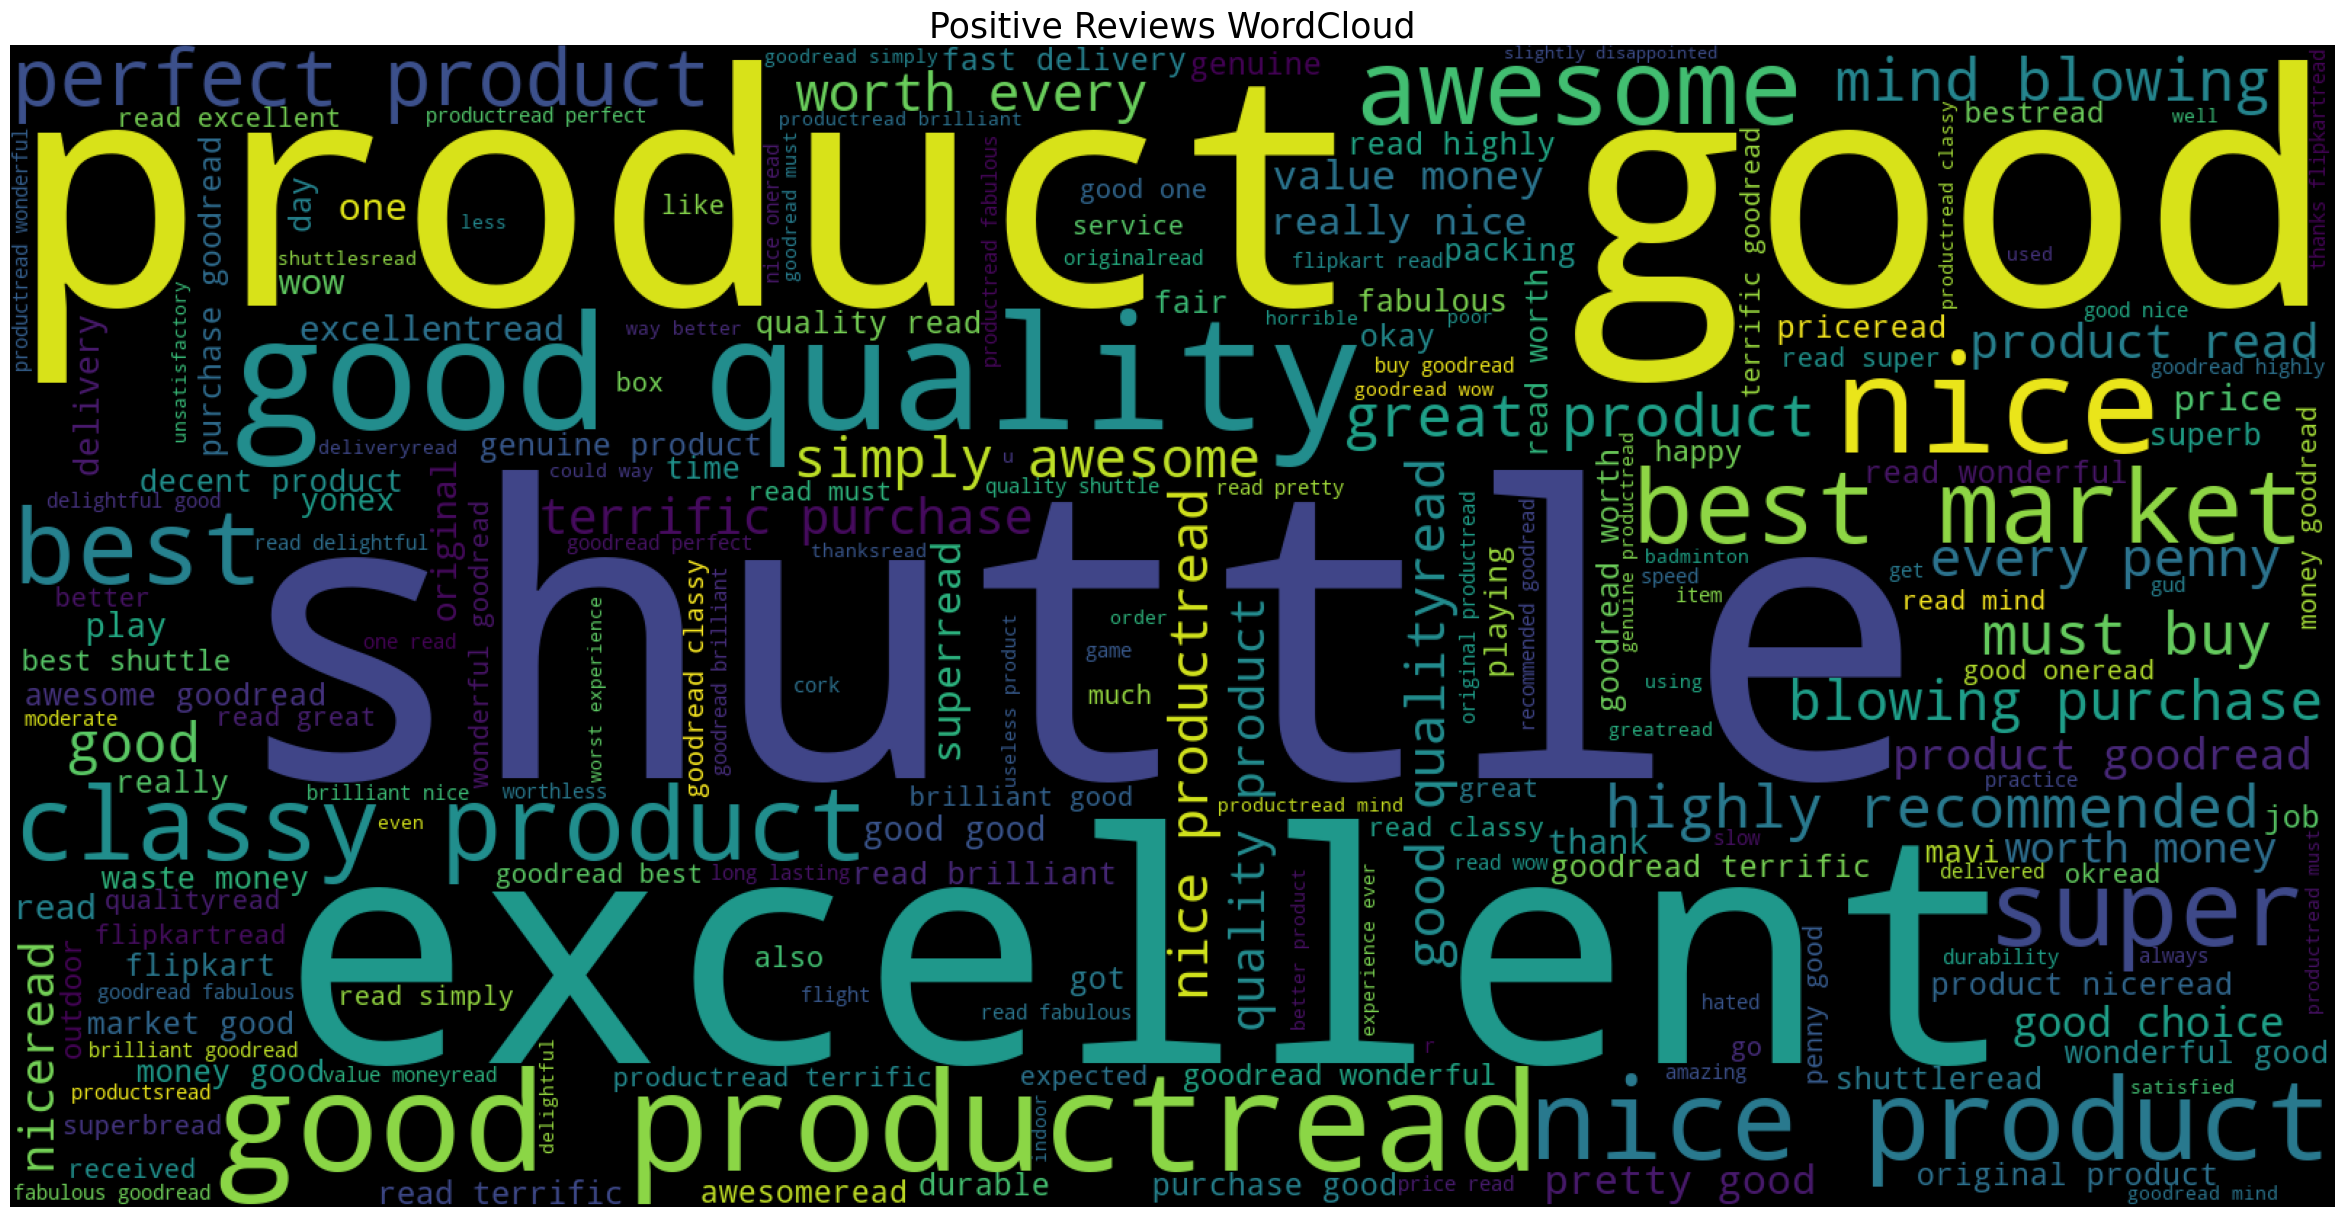

In [49]:
# Generate WordCloud
positive_wordcloud = WordCloud(
    stopwords=stop_words,
    background_color="black",
    width=1600,
    height=800
).generate(positive_words)

# Plot WordCloud
plt.figure(figsize=(30, 20))
plt.imshow(positive_wordcloud)
plt.axis("off")
plt.title("Positive Reviews WordCloud", fontsize=25)
plt.show()

### Plotting the Negative WordCloud

In [50]:
# Select only Negative reviews from training data
negative_reviews = X_train[y_train == "Negative"]

# Combine all reviews into a single string
negative_words = " ".join(negative_reviews)

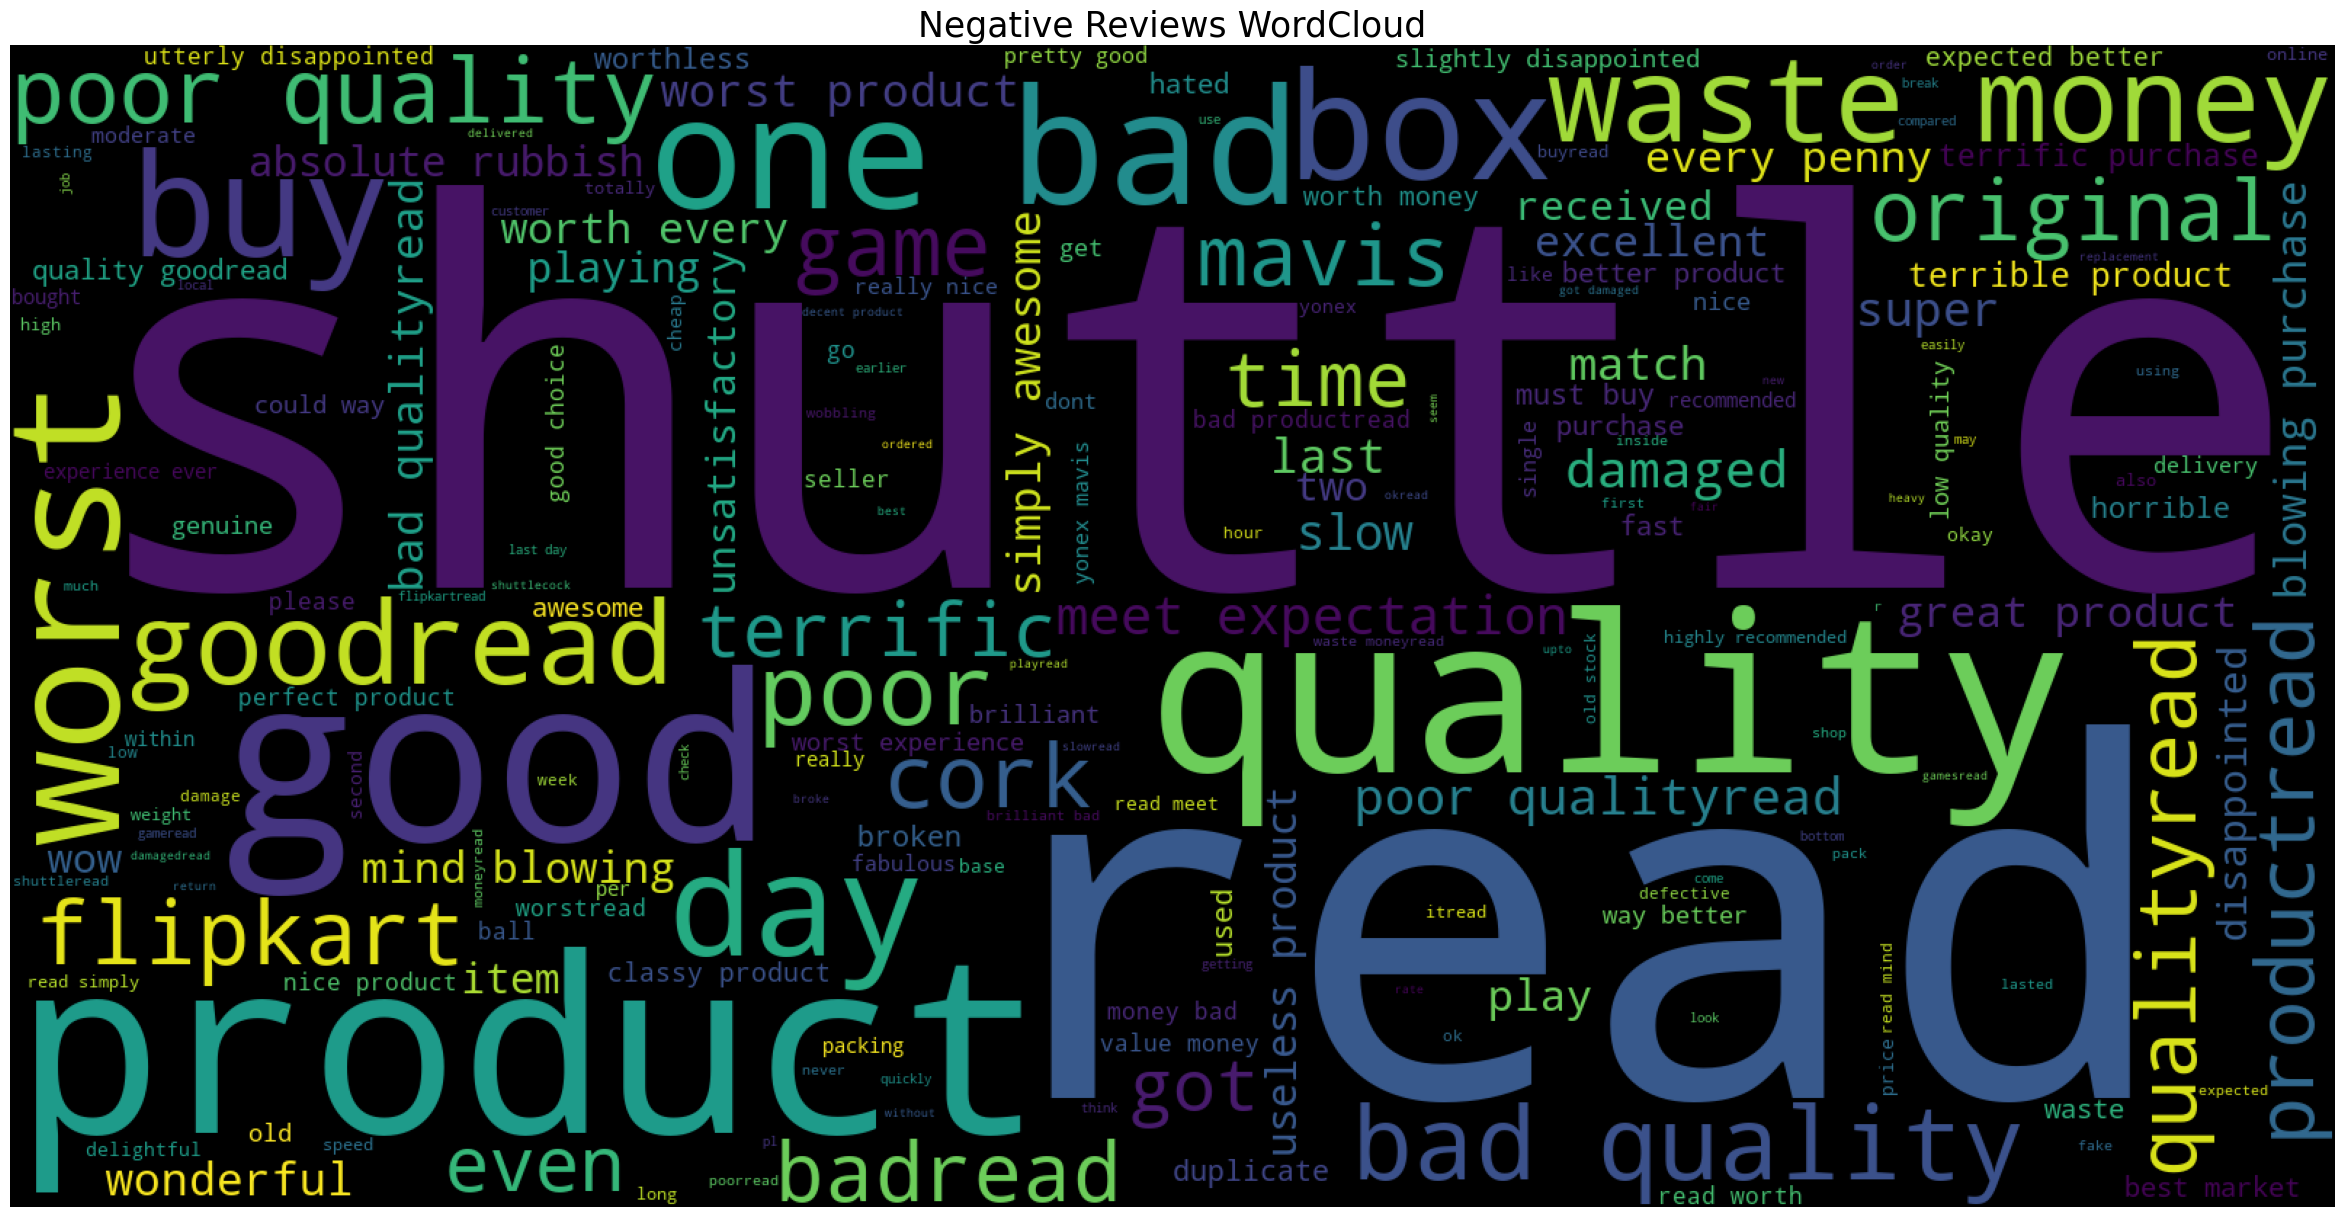

In [51]:
# Generate WordCloud
negative_wordcloud = WordCloud(
    stopwords=stop_words,
    background_color="black",
    width=1600,
    height=800
).generate(negative_words)

# Plot WordCloud
plt.figure(figsize=(30, 20))
plt.imshow(negative_wordcloud)
plt.axis("off")
plt.title("Negative Reviews WordCloud", fontsize=25)
plt.show()

### Plotting the Neutral WordCloud

In [52]:
# Select only Neutral reviews from training data
neutral_reviews = X_train[y_train == "Neutral"]

# Combine all reviews into a single string
neutral_words = " ".join(neutral_reviews)

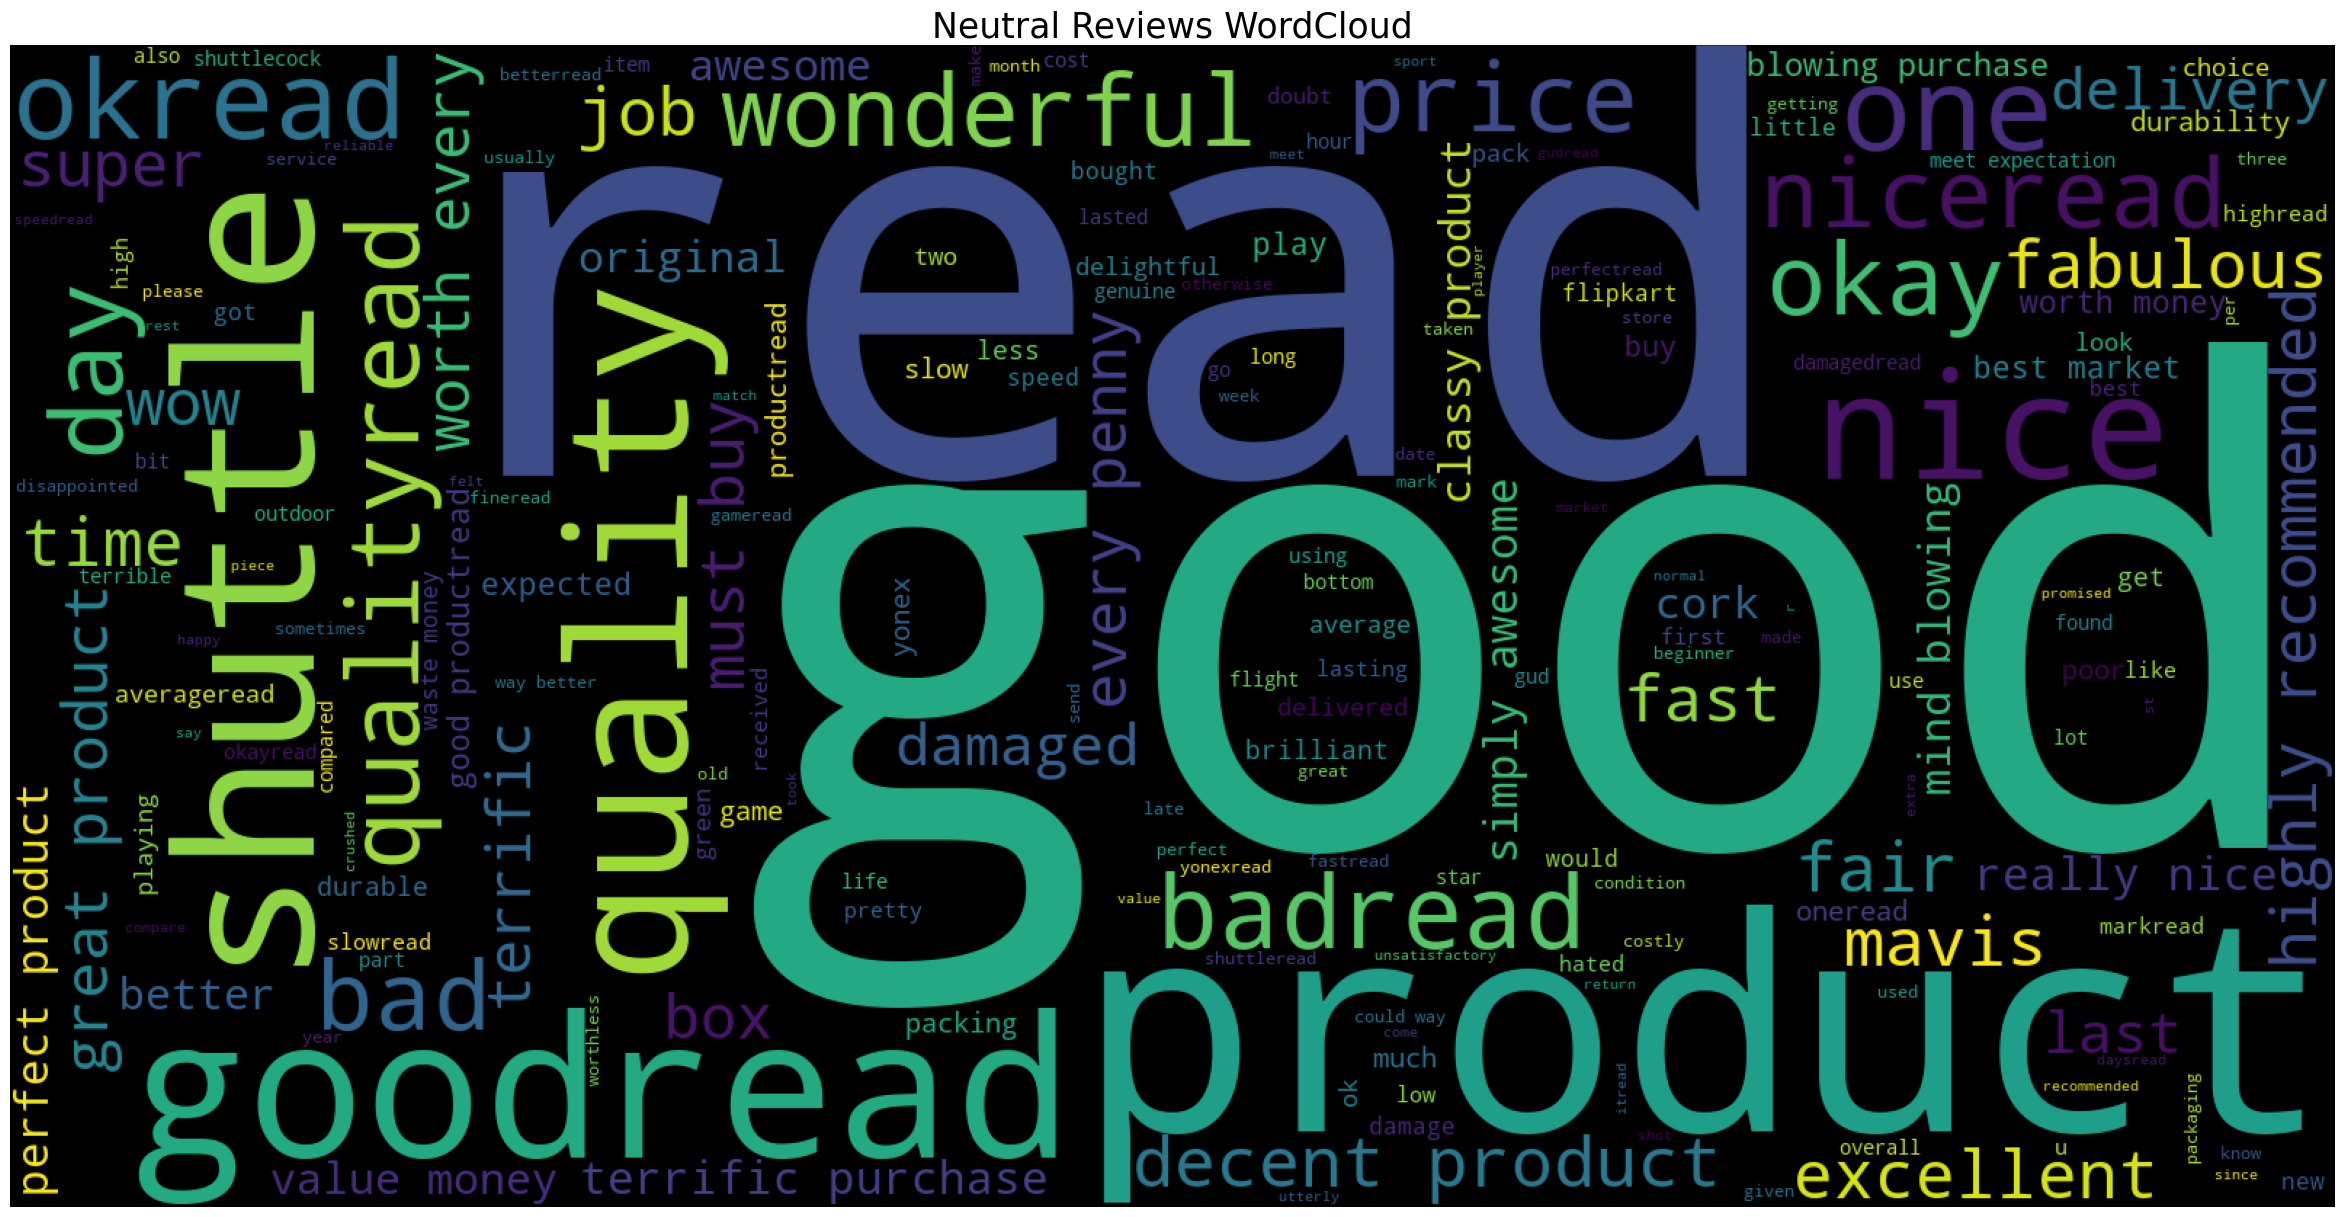

In [53]:
# Generate WordCloud
neutral_wordcloud = WordCloud(
    stopwords=stop_words,
    background_color="black",
    width=1600,
    height=800
).generate(neutral_words)

# Plot WordCloud
plt.figure(figsize=(30, 20))
plt.imshow(neutral_wordcloud)
plt.axis("off")
plt.title("Neutral Reviews WordCloud", fontsize=25)
plt.show()

## Feature Extraction

We convert textual reviews into numerical vectors using multiple NLP techniques.

**Methods Used**

1. Bag of Words (BoW)
2. TF-IDF

### BoW Feature Extraction

In [54]:
# Initialize CountVectorizer
# max_features limits vocabulary size to reduce sparsity
bow_vectorizer = CountVectorizer(max_features=5000)

# Fit BoW on training data and transform it
X_train_bow = bow_vectorizer.fit_transform(X_train)

# Transform test data using the same vocabulary
X_test_bow = bow_vectorizer.transform(X_test)

# Shape of BoW feature matrix
X_train_bow.shape

(6808, 2670)

### TF-IDF Feature Extraction

In [56]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Learn vocabulary and IDF weights from training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform test data using learned vocabulary
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Shape of TF-IDF feature matrix
X_train_tfidf.shape

(6808, 2670)

## Model Training & Evaluation

We evaluate multiple machine learning models using two different text feature extraction techniques:
- Bag of Words (BoW)
- TF-IDF

This helps identify the best model–feature combination for sentiment classification.

In [81]:
# Defining a helper function to evaluate all models

def evaluate_model(model, X_train_vec, X_test_vec, y_train, y_test):
    """
    Trains a model and returns accuracy and macro-averaged
    precision, recall, and F1-score using classification_report.
    """

    # Train model
    model.fit(X_train_vec, y_train)

    # Predict on test data
    y_pred = model.predict(X_test_vec)

    # Generate classification report as dictionary
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    # Extract required metrics
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Macro)": report["macro avg"]["precision"],
        "Recall (Macro)": report["macro avg"]["recall"],
        "F1 (Macro)": report["macro avg"]["f1-score"]
    }

    return metrics, report

In [82]:
# Create a dictionary of machine learning models
# Key = model name (string), Value = model object (untrained)
# This allows us to easily loop through each model for training and evaluation
models = {
    "KNN": KNeighborsClassifier(),                 # Distance-based classifier using nearest neighbors
    "Decision Tree": DecisionTreeClassifier(),    # Tree-based model using decision rules
    "Naive Bayes": MultinomialNB(),               # Fast probabilistic text classifier
    "Logistic Regression": LogisticRegression(), # Linear classifier for sentiment
    "Random Forest": RandomForestClassifier(),    # Ensemble of decision trees for better accuracy
    "SVM": LinearSVC()                            # Support Vector Machine for text data
}

In [83]:
# Evaluate all models on both Bag-of-Words (BoW) and TF-IDF features
results = []

for model_name, model in models.items():

    # BoW evaluation
    bow_metrics, _ = evaluate_model(
        model,
        X_train_bow,
        X_test_bow,
        y_train,
        y_test
    )

    # TF-IDF evaluation
    tfidf_metrics, _ = evaluate_model(
        model,
        X_train_tfidf,
        X_test_tfidf,
        y_train,
        y_test
    )

    # Store the results for later comparison
    results.append({
        "Model": model_name,

        "BoW Accuracy": bow_metrics["Accuracy"],
        "BoW Precision (Macro)": bow_metrics["Precision (Macro)"],
        "BoW Recall (Macro)": bow_metrics["Recall (Macro)"],
        "BoW F1 (Macro)": bow_metrics["F1 (Macro)"],

        "TF-IDF Accuracy": tfidf_metrics["Accuracy"],
        "TF-IDF Precision (Macro)": tfidf_metrics["Precision (Macro)"],
        "TF-IDF Recall (Macro)": tfidf_metrics["Recall (Macro)"],
        "TF-IDF F1 (Macro)": tfidf_metrics["F1 (Macro)"]
    })


In [84]:
# Create a DataFrame from results list to easily compare model F1-scores for BoW and TF-IDF
evaluation_df = pd.DataFrame(results)

# Display the comparison table
evaluation_df

,Model,BoW Accuracy,BoW Precision (Macro),BoW Recall (Macro),BoW F1 (Macro),TF-IDF Accuracy,TF-IDF Precision (Macro),TF-IDF Recall (Macro),TF-IDF F1 (Macro)
0,KNN,0.820799,0.600674,0.418987,0.441512,0.830200,0.637260,0.476448,0.513739
1,Decision Tree,0.819036,0.556585,0.508746,0.526378,0.804348,0.557643,0.526147,0.539487
2,Naive Bayes,0.846651,0.642584,0.500980,0.514894,0.824324,0.544347,0.397777,0.406303
3,Logistic Regression,0.856052,0.693947,0.554017,0.586387,0.855464,0.762790,0.520912,0.550914
4,Random Forest,0.853702,0.660645,0.520018,0.549666,0.850764,0.638516,0.511239,0.538236
5,SVM,0.851939,0.643700,0.565603,0.583491,0.856052,0.664810,0.557127,0.579548


In [78]:
# Sort the comparison table by TF-IDF F1-score in descending order to see the best model on top
evaluation_df.sort_values(by="TF-IDF F1 (Macro)", ascending=False)

,Model,BoW Macro F1,TF-IDF Macro F1
5,SVM,0.583491,0.579548
3,Logistic Regression,0.586387,0.550914
4,Random Forest,0.540407,0.542705
1,Decision Tree,0.528666,0.530242
0,KNN,0.441512,0.513739
2,Naive Bayes,0.514894,0.406303


#### Observations:
- All models achieve reasonably high accuracy (above 80%) across both feature extraction methods.
- However, accuracy alone does not reflect balanced sentiment classification, especially in a multi-class setting with Positive, Neutral, and Negative reviews.
- Macro-averaged precision, recall, and F1-score reveal significant differences in class-wise performance that accuracy hides.

#### Model Selection Rationale
- Support Vector Machine (SVM) demonstrates consistently strong and stable performance across both Bag of Words and TF-IDF features.
- The highest macro F1-score is achieved using Bag of Words with SVM, indicating the best balance between precision and recall across all sentiment classes.
- The marginal difference between feature extraction methods suggests that SVM is robust to text representation.

Based on macro F1-score and overall stability, Bag of Words combined with Linear SVM was selected as the best baseline model.

#### Explanation:
- The task involves three sentiment classes (Positive, Neutral, Negative) with uneven class distribution.
- Macro F1-score treats all classes equally and penalizes models that perform well only on the majority class.
- Using macro F1 ensures balanced sentiment classification rather than inflated performance driven by dominant classes.

Therefore, macro F1-score was selected as the primary metric for model comparison and selection.

## Hyperparameter Tuning & Regularization

In [88]:
# Define parameter grid
param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

# Initialize Linear SVM
svm = LinearSVC()

# Grid search with macro F1 as scoring metric
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

# Fit grid search
grid_search.fit(X_train_bow, y_train)

# Best model
best_svm = grid_search.best_estimator_

grid_search.best_params_

{'C': 1}

In [89]:
y_pred_best = best_svm.predict(X_test_bow)

print("Classification Report – Tuned SVM (BoW)")
print(classification_report(y_test, y_pred_best))

Classification Report – Tuned SVM (BoW)
              precision    recall  f1-score   support

    Negative       0.66      0.61      0.63       214
     Neutral       0.38      0.13      0.19       123
    Positive       0.89      0.95      0.92      1365

    accuracy                           0.85      1702
   macro avg       0.64      0.57      0.58      1702
weighted avg       0.83      0.85      0.83      1702



#### Observations:
- The tuned SVM achieves high overall accuracy (0.85), indicating strong general sentiment classification.
- Performance is excellent for Positive reviews, with consistently high precision and recall.
- Detection of Negative sentiment is reasonably balanced, while Neutral sentiment remains challenging due to ambiguous language.
- Macro F1-score is prioritized to ensure fair, class-balanced evaluation rather than accuracy dominated by positive samples.

**NOTE**: Hyperparameter tuning did not yield a significant improvement in macro F1-score, as the optimal regularization value matched the default setting. This result suggests that the baseline model was already well-regularized and that further performance gains are more likely to come from improved feature representations rather than parameter adjustments.

## Conclusion

Multiple machine learning models were evaluated for sentiment classification using Bag of Words and TF-IDF feature representations. While most models achieved comparable accuracy, macro F1-score was used as the primary evaluation metric to ensure balanced performance across Positive, Neutral, and Negative sentiment classes.

Among all evaluated combinations, Linear SVM consistently showed strong and stable performance. Hyperparameter tuning confirmed that the baseline configuration was already optimal, with no significant improvement observed after tuning. This indicates that further gains are more likely to come from feature-level improvements rather than parameter adjustments.

Based on these results, Bag of Words with Linear SVM was selected as the final model for implementation.